Dataset 1 Shape: (399, 4)
Dataset 2 Shape: (300, 15)
  Student_ID       Date    Subject Attendance_Status
0     S06592  9/20/2024     Arabic           Present
1     S01777  1/22/2025       Math           Present
2     S07362  12/3/2024  Geography          PRESENT 
3     S12119  3/16/2024  Geography           excused
4     S02002  5/24/2024       Math          PRESENT 
   student_id  age  gender    course      year parent_education  \
0           1   17    male  pharmacy  1st year      high school   
1           2   23   other   diploma  2nd year      high school   
2           3   22    male      b.sc  3rd year        no formal   
3           4   20   other  pharmacy  2nd year        no formal   
4           5   20  female  pharmacy  1st year        no formal   

  internet_access hostel_resident class_type weather  study_hours  \
0              no             yes    offline   sunny         3.63   
1             yes             yes    offline  cloudy         4.39   
2             yes  

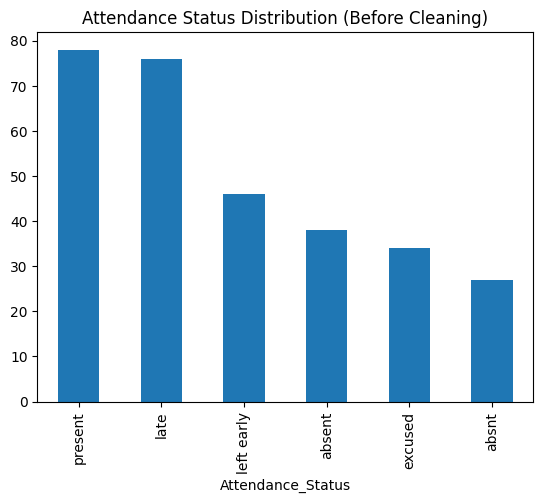


Merged Dataset Shape: (12, 18)
   Student_ID        Date  Subject Attendance_Status  age  gender course  \
0          98  10/22/2024  History              late   22   other   b.sc   
1          92   1/15/2025  Science              late   23  female    bca   
2          98    1/8/2025  Science              late   22   other   b.sc   
3         143   4/30/2024   Arabic              late   19  female     ba   
4         293  10/10/2024  English           excused   24   other     ba   

       year parent_education internet_access hostel_resident class_type  \
0  1st year         graduate             yes             yes     online   
1  4th year        no formal             yes              no    offline   
2  1st year         graduate             yes             yes     online   
3  3rd year    post graduate             yes              no     online   
4  1st year        no formal              no              no    offline   

  weather  study_hours  sleep_hours  travel_time_minutes  at

In [2]:
# ================================
# STEP 1: Import Libraries
# ================================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# ================================
# STEP 2: Load Datasets
# ================================
df1 = pd.read_csv("attendance1(Sheet1).csv")
df2 = pd.read_csv("Attendance_Prediction 1(Sheet1).csv")

print("Dataset 1 Shape:", df1.shape)
print("Dataset 2 Shape:", df2.shape)

# ================================
# STEP 3: Display First Rows
# ================================
print(df1.head())
print(df2.head())

# ================================
# STEP 4: Check Missing Values
# ================================
print("\nMissing Values Dataset 1:")
print(df1.isnull().sum())

print("\nMissing Values Dataset 2:")
print(df2.isnull().sum())

# ================================
# STEP 5: Data Cleaning
# ================================

# Standardize text values (important)
df1["Attendance_Status"] = df1["Attendance_Status"].str.lower().str.strip()
df2.columns = df2.columns.str.strip()

# Fill missing values for Attendance_Status
df1["Attendance_Status"] = df1["Attendance_Status"].fillna("absent")

# --- Address Student_ID for merging consistency ---
# Rename 'student_id' in df2 to 'Student_ID'
if 'student_id' in df2.columns:
    df2.rename(columns={'student_id': 'Student_ID'}, inplace=True)

# Process Student_ID in df1: extract numeric part and convert to int
# Convert to string first to handle potential mixed types and enable .str methods.
# Extract numeric part. .iloc[:, 0] is needed because str.extract returns a DataFrame.
df1['Student_ID'] = df1['Student_ID'].astype(str).str.extract(r'(\d+)').iloc[:, 0]
# Convert extracted string to numeric, coercing errors (e.g., if original was NaN or not just digits)
df1['Student_ID'] = pd.to_numeric(df1['Student_ID'], errors='coerce')
# Drop rows where Student_ID became NaN after conversion, as these won't merge meaningfully.
df1.dropna(subset=['Student_ID'], inplace=True)
# Finally, convert to integer type
df1['Student_ID'] = df1['Student_ID'].astype(int)

# Ensure Student_ID in df2 is integer type
df2['Student_ID'] = pd.to_numeric(df2['Student_ID'], errors='coerce')
# Drop rows where Student_ID couldn't be converted or was NaN
df2.dropna(subset=['Student_ID'], inplace=True)
df2['Student_ID'] = df2['Student_ID'].astype(int)

# ================================
# STEP 6: Visualization (Before)
# ================================
df1["Attendance_Status"].value_counts().plot(kind="bar")
plt.title("Attendance Status Distribution (Before Cleaning)")
plt.show()

# ================================
# STEP 7: Merge Datasets
# ================================
merged = pd.merge(df1, df2, on="Student_ID", how="inner")

print("\nMerged Dataset Shape:", merged.shape)
print(merged.head())

# ================================
# STEP 8: Feature Engineering
# ================================

# Convert attendance to binary
merged["Present_Flag"] = merged["Attendance_Status"].apply(
    lambda x: 1 if x == "present" else 0
)

# Create attendance percentage per student
attendance_summary = merged.groupby("Student_ID")["Present_Flag"].mean().reset_index()
attendance_summary.rename(columns={"Present_Flag": "Attendance_Percentage"}, inplace=True)

# Merge back
merged = pd.merge(merged, attendance_summary, on="Student_ID")

# ================================
# STEP 9: Drop Unnecessary Columns
# ================================
merged.drop(["Date"], axis=1, inplace=True, errors="ignore")

# ================================
# STEP 10: Encoding (for WEKA / ML)
# ================================
le = LabelEncoder()

for col in merged.select_dtypes(include="object").columns:
    merged[col] = le.fit_transform(merged[col])

# ================================
# STEP 11: Save Final Dataset
# ================================
merged.to_csv("final_attendance_dataset.csv", index=False)

print("\nFinal dataset saved as 'final_attendance_dataset.csv'")

# ================================
# STEP 12: Create Apriori Dataset
# ================================
apriori_data = merged[[
    "Student_ID",
    "Subject",
    "Attendance_Status",
    "Attendance_Percentage"
]]

apriori_data.to_csv("apriori_dataset.csv", index=False)

print("Apriori dataset saved as 'apriori_dataset.csv'")
